#SOM + RBF Hybrid Neural Network Project
# Customer Segmentation + Prediction System

importing required libraries:

1. Pandas
2. Numpy
3. Matplotlib
4. Seaborn
5. Sklearn
6. Minisom

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

!pip install minisom
from minisom import MiniSom


  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=4f4312962fe5d13f3a6277feff5ac1124cfe65ba7537abf233e83dde007da21b
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


After importing libraries , now we have to read dataset

In [3]:
df = pd.read_csv("/content/Mall_Customers.csv")
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Finding shape

In [4]:
df.shape

(200, 5)

Finding information


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Data Processing:

- Removing unnecessary columns
- Normalizes data (specific need for SOM)
- WHY scaler-
     
     ML Algos perform better when numeric data is on similar scale.

- MinMaxScaler
  - range(0 to 1),
              
  - high value like ("Annual income") doesn't overpower small value like ("Age")

In [6]:
x = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

VISUALIZATION:
- Age and Annual Income are two main feature, using a scatterplot to show the relationship.

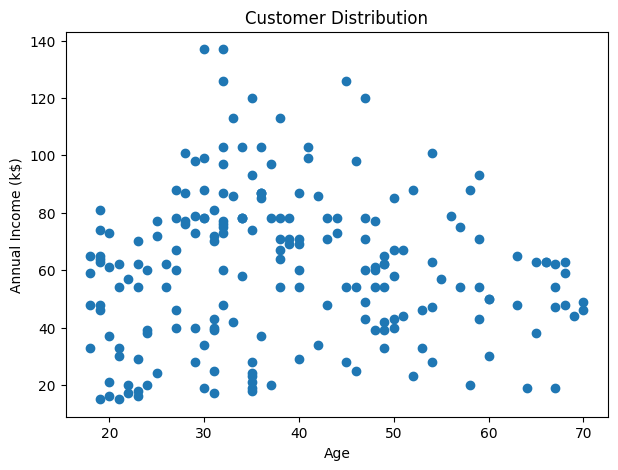

In [7]:
plt.figure(figsize=(7,5))

plt.scatter(df['Age'],
            df['Annual Income (k$)'])

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("Customer Distribution")

plt.show()


BUILDING SOM:

 - creates 5*5 grid of neurons.
 - each data point has 3 features.
 - intial weights of the neurons randomly based on the input data(x_scaled)
 - trains SOM for 100 iterations by picking random samples.

In [8]:
som = MiniSom(x=5, y=5, input_len=3, sigma=1.0, learning_rate=0.5)
som.random_weights_init(x_scaled)
som.train_random(x_scaled, 100)

Visualizing SOM:

- initializes a square plot
- iterates each data point in scaled dataset
- [ winner = som.winner(x)] -> For each data point, it finds the 'winning' neurons on SOM grid.
- plt.scatter(...) --> location of winner neuron. prevent dots from stacking directly on each other, making density of the clusters visible.
- plt.show() --> Final scatter plot showwing how customer groups across the map.


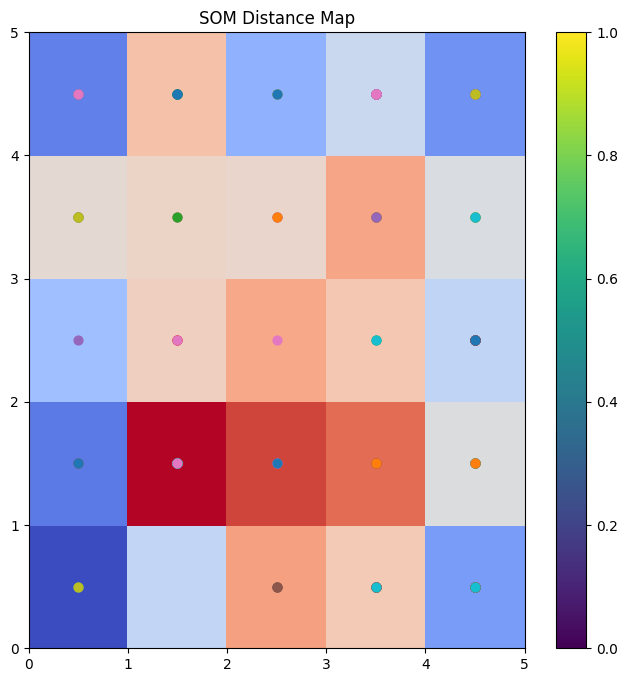

In [9]:
plt.figure(figsize=(8,8))

plt.pcolor(som.distance_map().T, cmap='coolwarm')

for x in x_scaled:

    winner = som.winner(x)

    plt.scatter(
        winner[0] + 0.5,
        winner[1] + 0.5,
        s=40
    )

plt.colorbar()

plt.title("SOM Distance Map")

plt.show()


ASSIGN CLUSTER LABELS:

- winner = som.winner(x) --> Best matching Unit on SOM grid.
- converting 2d grid to 1d ID for simplification.
- clusters.append(cluster_id) --> stores ID for each row in a list.
- the adds a new column named 'Cluster' to assign specific SOM neuron.



In [10]:
clusters = []

for x in x_scaled:

    winner = som.winner(x)

    cluster_id = winner[0] * 5 + winner[1]

    clusters.append(cluster_id)

df['Cluster'] = clusters

print("\nClustered Data:\n")

print(df[['CustomerID', 'Cluster']].head())



Clustered Data:

   CustomerID  Cluster
0           1       23
1           2       15
2           3       23
3           4       15
4           5        3


DATA PREPARATION FOR RBF:

- Three independent variables from data set are chosen.

  - ['Spending Score (1-100)'] is not chosen in x_rbf , as it can lead to data leakage, so in result it will show near perfect accuracy during training but will fail completely on new data where spending data score isn't already known.
- target variable is decided.

In [11]:
X_rbf = df[['Age',
            'Annual Income (k$)',
            'Cluster']]

y = df['Spending Score (1-100)']

In [12]:
scaler_rbf = MinMaxScaler()

X_rbf_scaled = scaler_rbf.fit_transform(X_rbf)

Creating RBF Feature:

- using weights from a self-organizing Map for the "centers".
- [cdist(X, centers)]Computes Euclidean Distance between every pair of points.
- [np.exp(
        -gamma * cdist(X, centers)**2
    )] --> Gaussian RBF formula.

- x_feature = rbf(...) --> creates new feature matrix.


In [22]:
from scipy.spatial.distance import cdist

centers = som.get_weights().reshape(-1, 3)

def rbf(X, centers, gamma=5.0):

    return np.exp(
        -gamma * cdist(X, centers)**2
    )

X_features = rbf(X_rbf_scaled, centers)

Train and Test Split:

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

predictions = model.predict(x_test)

TRAIN RBF MODEL:


EVALUATE MODEL:

- calculate Mean Squared Error, Root Meana Squared Error, R2 Score.

In [24]:
from sklearn.metrics import r2_score,mean_squared_error
import numpy as np

predictions = model.predict(x_test)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE : 211.5250232228534
RMSE: 14.543899862927185
R2 Score: 0.5711519276156569


Visualize Prediction:


This scatter plot compares actual spending scores with predicted values from the RBF model. The diagonal reference line represents ideal predictions. Points closer to the line indicate better model performance.


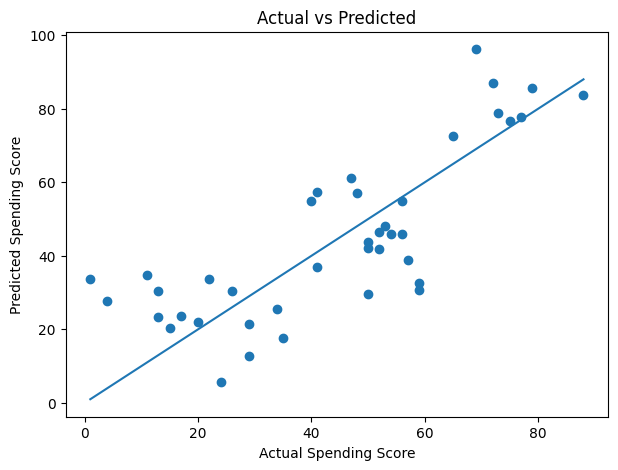

In [25]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Spending Score")
plt.ylabel("Predicted Spending Score")

plt.title("Actual vs Predicted")

plt.show()

In [26]:
print("\nFinal Dataset:\n")

print(df.head())



Final Dataset:

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0       23  
1       15  
2       23  
3       15  
4        3  


#SOM + RBF PROJECT COMPLETED

